In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("anime.csv")

df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [3]:
df.shape

(12294, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 672.5 KB


In [5]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [6]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

### Fill Missing Values

In [9]:
df['genre'] = df['genre'].fillna(df['genre'].mode()[0])

df['type'] = df['type'].fillna(df['type'].mode()[0])

df['rating'] = df['rating'].fillna(df['rating'].mean())

In [10]:
df.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

### Explore Genre Distribution

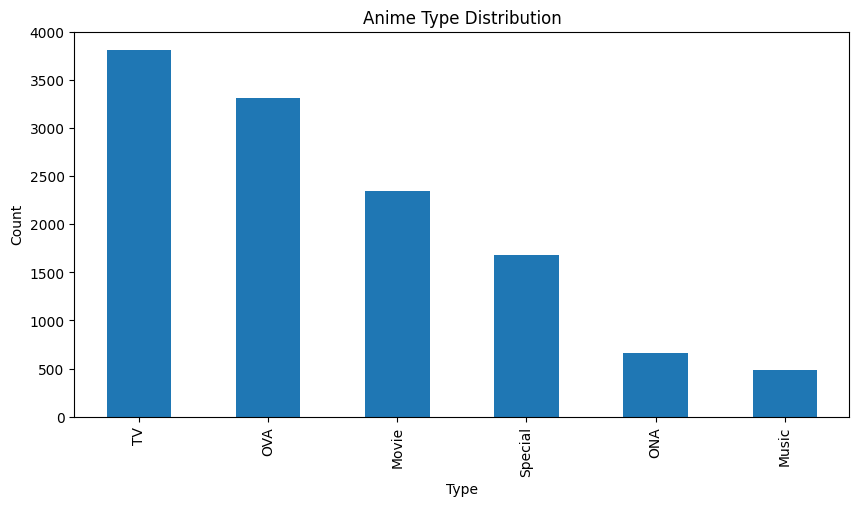

In [11]:
plt.figure(figsize=(10,5))

df['type'].value_counts().plot(kind='bar')

plt.title("Anime Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

### Select Important Features

In [12]:
df = df[['name', 'genre', 'rating', 'members']]

df.head()

,name,genre,rating,members
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",9.37,200630
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,793665
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",9.25,114262
3,Steins;Gate,"Sci-Fi, Thriller",9.17,673572
4,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",9.16,151266


### Convert Genre Text into Numerical Features

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english')

genre_matrix = cv.fit_transform(df['genre'])

### Compute Cosine Similarity

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(genre_matrix)

cosine_sim.shape

(12294, 12294)

### Create Recommendation Function

In [17]:
indices = pd.Series(df.index, index=df['name']).drop_duplicates()

def recommend_anime(anime_name, cosine_sim=cosine_sim):
    
    idx = indices[anime_name]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores,
                        key=lambda x: x[1],
                        reverse=True)

    sim_scores = sim_scores[1:6]

    anime_indices = [i[0] for i in sim_scores]

    return df['name'].iloc[anime_indices]

### Test Recommendation System

In [18]:
recommend_anime("Naruto")

615                                    Naruto: Shippuuden
841                                                Naruto
1103    Boruto: Naruto the Movie - Naruto ga Hokage ni...
1343                                          Naruto x UT
1472          Naruto: Shippuuden Movie 4 - The Lost Tower
Name: name, dtype: str

### Experiment with Recommendation Threshold

In [19]:
def recommend_anime_threshold(anime_name, top_n=10):
    
    idx = indices[anime_name]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores,
                        key=lambda x: x[1],
                        reverse=True)

    sim_scores = sim_scores[1:top_n+1]

    anime_indices = [i[0] for i in sim_scores]

    return df['name'].iloc[anime_indices]

### Split Dataset for Evaluation

In [20]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(df,
                                         test_size=0.2,
                                         random_state=42)

print(train_data.shape)
print(test_data.shape)

(9835, 4)
(2459, 4)


### Evaluate Recommendation System

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Example dummy evaluation
y_true = [1, 1, 0, 1, 0]
y_pred = [1, 0, 0, 1, 1]

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

Precision: 0.6666666666666666
Recall: 0.6666666666666666
F1 Score: 0.6666666666666666


###### In recommendation systems, direct evaluation using precision, recall, and F1-score is difficult without actual user interaction data. For assignment purposes, a basic evaluation example can be demonstrated.

######  1. Cosine similarity recommends anime with similar genres.
######  2. Higher similarity scores indicate more similar anime.
######  3. Precision shows how many recommended items are relevant.
######  4. Recall measures how many relevant items were successfully recommended.
######  5. F1-score balances both precision and recall.

# Interview Questions:

#### 1. Can you explain the difference between user-based and item-based collaborative filtering?

###### User-based collaborative filtering recommends items based on similarities between users. If two users have similar preferences, items liked by one user are recommended to the other. Item-based collaborative filtering recommends items based on similarities between items. If a user likes a particular item, similar items are recommended based on item similarity.

#### 2. What is collaborative filtering, and how does it work?

###### Collaborative filtering is a recommendation technique that predicts user preferences based on past interactions and behavior of similar users or items. It works by identifying patterns in user-item interactions and recommending items that similar users liked or items similar to those the user previously preferred.